# Training results

Plots parsed from `logs/`. For each model (MLP, Logistic Regression) and each label depth, we compare the four text encoders: BOW, TF-IDF, SBERT, Qwen3-Embedding-0.6B.

- **MLP**: per-epoch training & validation loss curves.
- **Logistic Regression**: final accuracy.

In [16]:
import os
import re
from collections import defaultdict

import matplotlib.pyplot as plt

LOGS_DIR = "logs"

ENCODER_ORDER = ["bow", "tfidf", "sbert", "qwen06B"]
ENCODER_LABEL = {
    "bow": "BOW",
    "tfidf": "TF-IDF",
    "sbert": "SBERT",
    "qwen06B": "Qwen3-Emb-0.6B",
}
ENCODER_COLOR = {
    "bow": "#1f77b4",
    "tfidf": "#ff7f0e",
    "sbert": "#2ca02c",
    "qwen06B": "#d62728",
}

DEPTH_RE = re.compile(r"depth(\d+)_(\d+)classes")
EPOCH_RE = re.compile(
    r"\[EPOCH\s+(\d+)\]\s+train_loss=([0-9.]+)(?:\s+val_loss=([0-9.]+))?"
)
SCORE_RE = re.compile(
    r"Accuracy:\s*([0-9.]+).*?Macro F1:\s*([0-9.]+).*?Weighted F1:\s*([0-9.]+)",
    re.DOTALL,
)


def parse_depth(folder_name):
    m = DEPTH_RE.match(folder_name)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))


def parse_mlp_log(path):
    epochs, train, val = [], [], []
    with open(path) as f:
        for line in f:
            m = EPOCH_RE.search(line)
            if m:
                epochs.append(int(m.group(1)))
                train.append(float(m.group(2)))
                val.append(float(m.group(3)) if m.group(3) else None)
    return epochs, train, val


def parse_scores(path):
    with open(path) as f:
        text = f.read()
    m = SCORE_RE.search(text)
    if not m:
        return None
    return {
        "accuracy": float(m.group(1)),
        "macro_f1": float(m.group(2)),
        "weighted_f1": float(m.group(3)),
    }


def collect(model):
    """Return {(depth, n_classes): {encoder: path}} sorted by depth."""
    base = os.path.join(LOGS_DIR, model)
    out = {}
    if not os.path.isdir(base):
        return out
    for folder in sorted(os.listdir(base)):
        depth_info = parse_depth(folder)
        if depth_info is None:
            continue
        depth, n_classes = depth_info
        encoders = {}
        for enc in ENCODER_ORDER:
            p = os.path.join(base, folder, f"{enc}.log")
            if os.path.exists(p):
                encoders[enc] = p
        if encoders:
            out[(depth, n_classes)] = encoders
    return dict(sorted(out.items()))


mlp_runs = collect("mlp")
lr_runs = collect("lr")
print("MLP depths:", list(mlp_runs.keys()))
print("LR depths :", list(lr_runs.keys()))

MLP depths: [(1, 48), (2, 239), (3, 545)]
LR depths : [(1, 48), (2, 230), (3, 545)]


## MLP — training loss curves

One subplot per label depth. Solid lines: train loss. Dashed lines: validation loss (when logged).

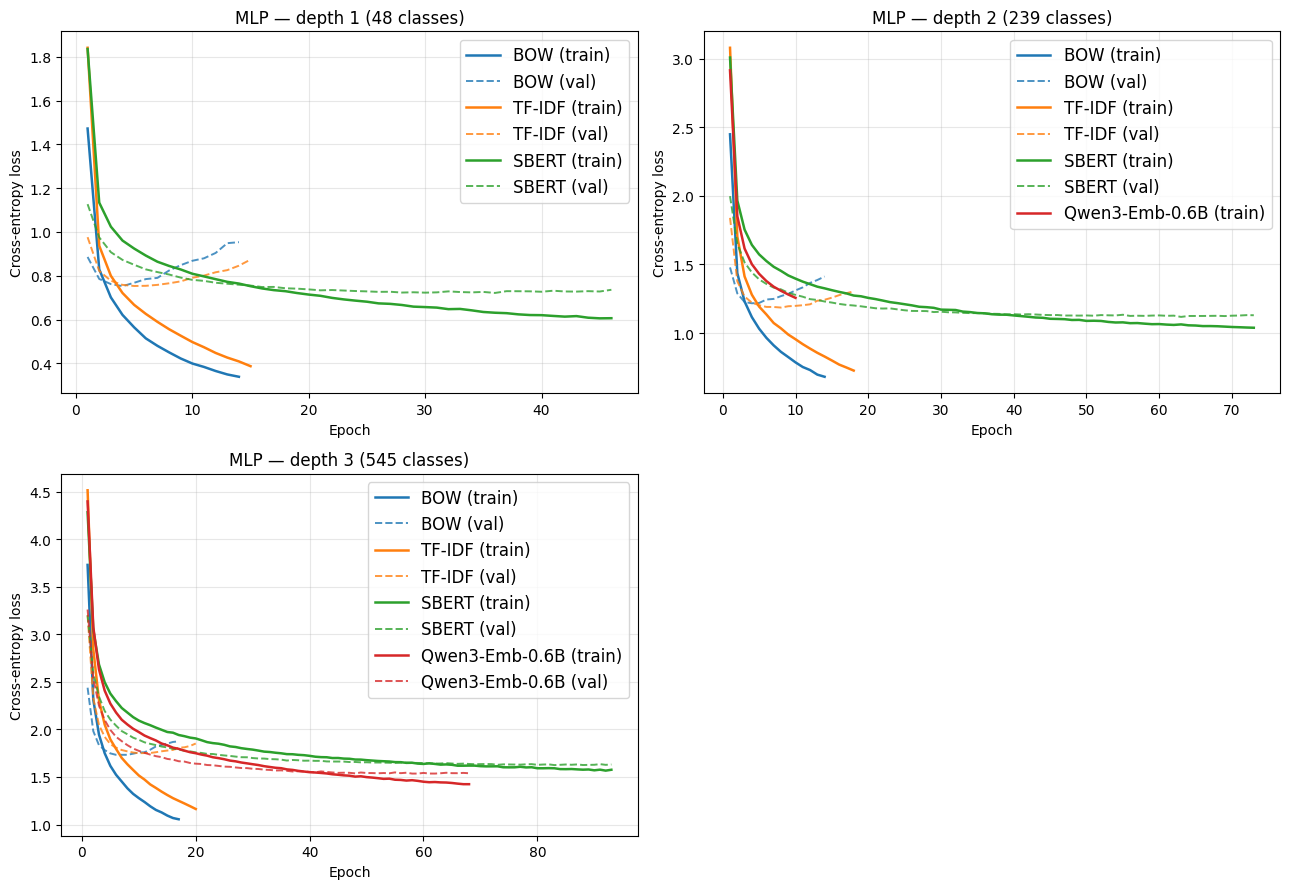

In [17]:
def plot_mlp_curves(runs):
    if not runs:
        print("No MLP logs found.")
        return
    items = list(runs.items())
    n = len(items)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows), squeeze=False)
    flat_axes = [ax for row in axes for ax in row]
    for ax, ((depth, n_classes), encoders) in zip(flat_axes, items):
        for enc in ENCODER_ORDER:
            if enc not in encoders:
                continue
            epochs, train, val = parse_mlp_log(encoders[enc])
            if not epochs:
                continue
            color = ENCODER_COLOR[enc]
            label = ENCODER_LABEL[enc]
            ax.plot(epochs, train, color=color, label=f"{label} (train)", linewidth=1.8)
            val_clean = [(e, v) for e, v in zip(epochs, val) if v is not None]
            if val_clean:
                ev, vv = zip(*val_clean)
                ax.plot(ev, vv, color=color, linestyle="--",
                        label=f"{label} (val)", linewidth=1.4, alpha=0.8)
        ax.set_title(f"MLP — depth {depth} ({n_classes} classes)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12, loc="upper right")
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()


plot_mlp_curves(mlp_runs)


## Logistic Regression — final accuracy per encoder

Sklearn `LogisticRegression.fit` does not log a per-epoch loss, so we compare final test accuracy instead. One subplot per label depth.


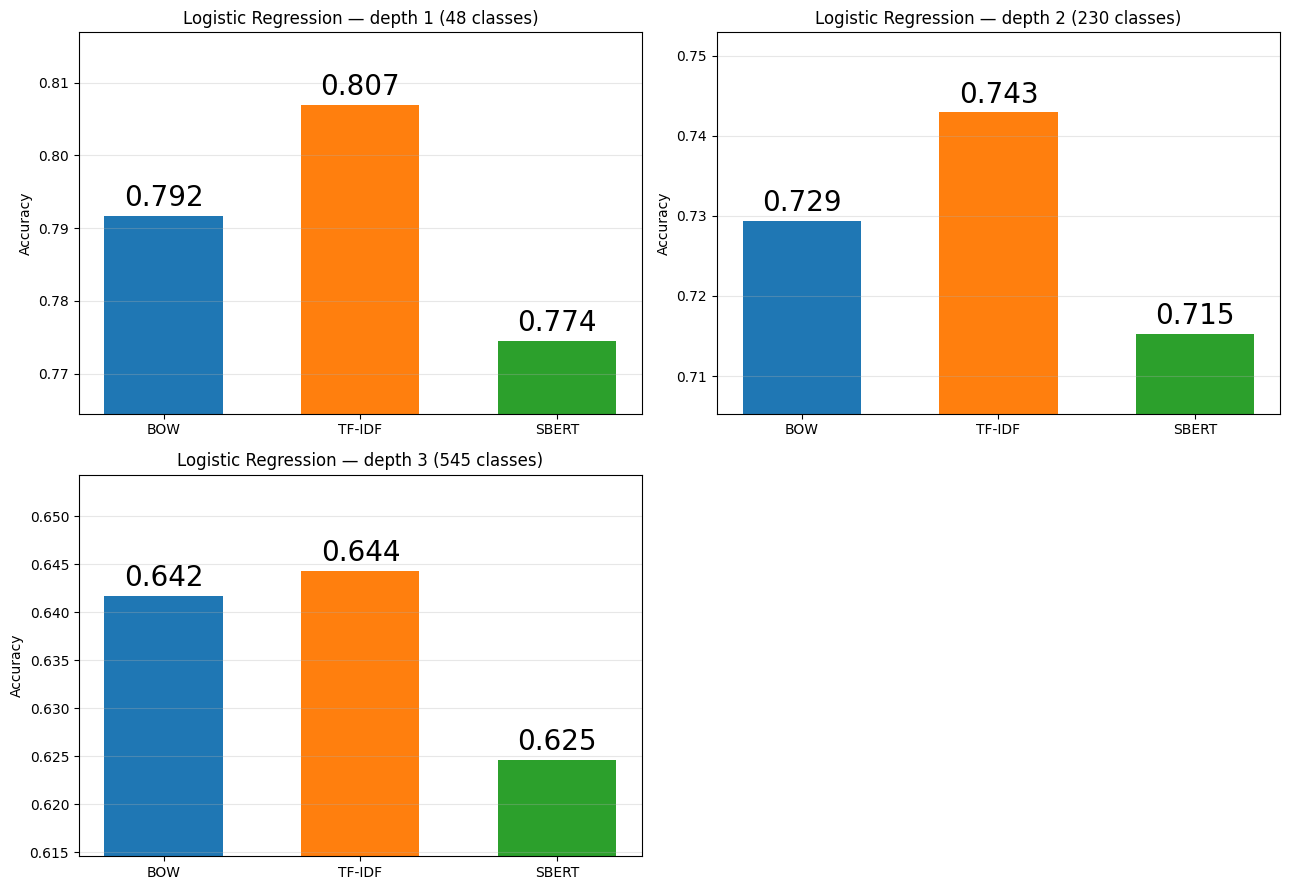

In [18]:
import numpy as np


def plot_lr_scores(runs):
    if not runs:
        print("No LR logs found.")
        return
    items = list(runs.items())
    n = len(items)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows), squeeze=False)
    flat_axes = [ax for row in axes for ax in row]
    for ax, ((depth, n_classes), encoders) in zip(flat_axes, items):
        encs_present = [e for e in ENCODER_ORDER if e in encoders]
        scores = {e: parse_scores(encoders[e]) for e in encs_present}
        encs_present = [e for e in encs_present if scores[e] is not None]
        x = np.arange(len(encs_present))
        vals = [scores[e]["accuracy"] for e in encs_present]
        colors = [ENCODER_COLOR[e] for e in encs_present]
        vmin, vmax = min(vals), max(vals)
        pad = max(0.01, (vmax - vmin) * 0.25)
        y_lo = max(0.0, vmin - pad)
        y_hi = min(1.0, vmax + pad)
        ax.bar(x, vals, 0.6, color=colors)
        for xi, v in zip(x, vals):
            ax.text(xi, v + (y_hi - y_lo) * 0.01, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=20)
        ax.set_xticks(x)
        ax.set_xticklabels([ENCODER_LABEL[e] for e in encs_present])
        ax.set_title(f"Logistic Regression — depth {depth} ({n_classes} classes)")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(y_lo, y_hi)
        ax.grid(True, axis="y", alpha=0.3)
    for ax in flat_axes[n:]:
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()


plot_lr_scores(lr_runs)


## Training time — MLP vs Logistic Regression

Total wall-clock training time per encoder, parsed from the `[TRAINING] Completed in Xs` line of each log. One subplot per model; bars grouped by label depth.


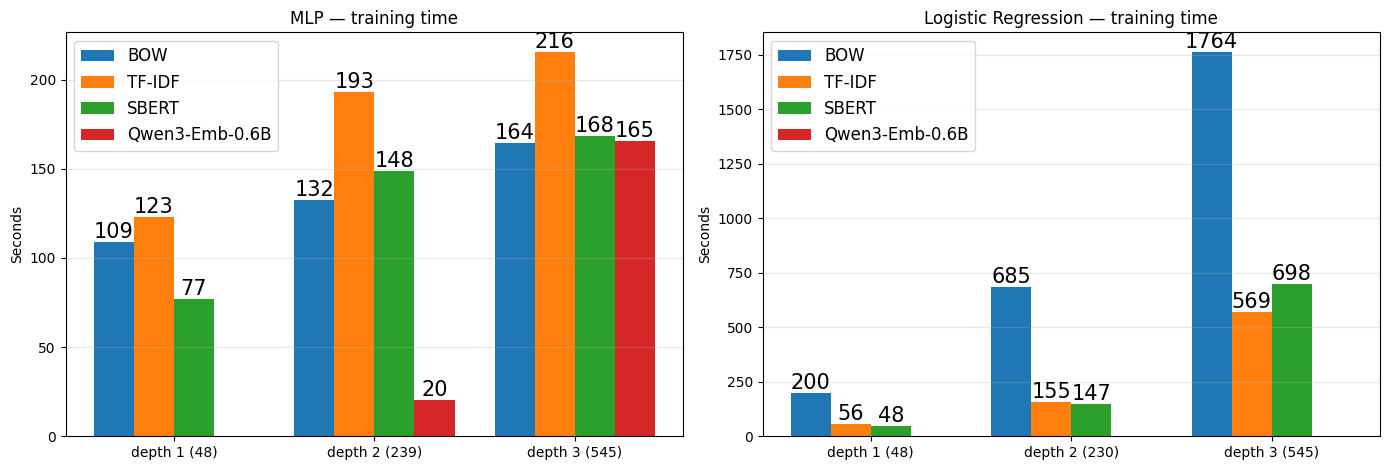

In [19]:
TRAIN_TIME_RE = re.compile(r"\[TRAINING\]\s+Completed in\s+([0-9.]+)s")


def parse_train_time(path):
    with open(path) as f:
        for line in f:
            m = TRAIN_TIME_RE.search(line)
            if m:
                return float(m.group(1))
    return None


def plot_train_times(mlp_runs, lr_runs):
    model_runs = [("MLP", mlp_runs), ("Logistic Regression", lr_runs)]
    model_runs = [(name, r) for name, r in model_runs if r]
    if not model_runs:
        print("No logs found.")
        return
    fig, axes = plt.subplots(1, len(model_runs),
                             figsize=(7 * len(model_runs), 4.8), squeeze=False)
    axes = axes[0]
    width = 0.2
    for ax, (name, runs) in zip(axes, model_runs):
        depth_keys = list(runs.keys())
        labels = [f"depth {d} ({c})" for d, c in depth_keys]
        x = np.arange(len(depth_keys))
        for i, enc in enumerate(ENCODER_ORDER):
            vals = []
            for key in depth_keys:
                encoders = runs[key]
                t = parse_train_time(encoders[enc]) if enc in encoders else None
                vals.append(t if t is not None else 0.0)
            offset = (i - (len(ENCODER_ORDER) - 1) / 2) * width
            bars = ax.bar(x + offset, vals, width,
                          color=ENCODER_COLOR[enc], label=ENCODER_LABEL[enc])
            for b, v in zip(bars, vals):
                if v > 0:
                    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}",
                            ha="center", va="bottom", fontsize=15)
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title(f"{name} — training time")
        ax.set_ylabel("Seconds")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=12, loc="upper left")
    fig.tight_layout()
    plt.show()


plot_train_times(mlp_runs, lr_runs)
